# Project on Linear Regression
This project is a systematic, step-by-step benchmarking experiment. Using the classic California Housing dataset, it builds, tests, and compares 30 different variations of linear regression models.The goal here isn't just to build one good model, but to show how different machine learning techniques—like feature selection, scaling, polynomial transformation, and regularization—impact a model's performance ($R^2$ score) and behavior.

---
### Imports and Data Loading

This cell sets up the environment and prepares the data.

- **The Dataset:** It loads the California Housing dataset, where the goal is to predict the median house value (Target) based on 8 features (like median income, house age, average rooms, and geographic coordinates).

- **The Split:** It splits the data into a Training set (80%) to teach the models and a Testing set (20%) to evaluate how well they actually learned. Keeping a random state of 42 ensures that the data splits exactly the same way every time you run it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Load Data
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target
X = df.drop('Target', axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

---
### Section 1 - Basic Linear Regression Variations (1-5)

Here, the project tests how the choice of features impacts the model. It runs standard Linear Regression 5 times, each time giving the model a different set of inputs:
- Models 1–3: Test small groups of economic/structural features (e.g., just MedInc vs. MedInc + HouseAge).
- Model 4: Tests purely geographical features (Latitude and Longitude).
- Model 5: Uses all available features.
- Takeaway: This demonstrates that features aren't created equal. For instance, Median Income (MedInc) is usually the strongest predictor in this dataset, while geography alone performs quite differently.

In [2]:
# Variations: Different subsets of features
feature_sets = [
    ['MedInc'], ['MedInc', 'HouseAge'], ['MedInc', 'AveRooms', 'AveBedrms'],
    ['Latitude', 'Longitude'], X.columns.tolist()
]

results = []
for i, features in enumerate(feature_sets):
    model = LinearRegression()
    model.fit(X_train[features], y_train)
    score = model.score(X_test[features], y_test)
    results.append(f"Model {i+1} (Features {features}): R2 = {score:.4f}")

for res in results: print(res)

Model 1 (Features ['MedInc']): R2 = 0.4589
Model 2 (Features ['MedInc', 'HouseAge']): R2 = 0.4941
Model 3 (Features ['MedInc', 'AveRooms', 'AveBedrms']): R2 = 0.4842
Model 4 (Features ['Latitude', 'Longitude']): R2 = 0.2530
Model 5 (Features ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']): R2 = 0.5758


---
### Section 2 - Feature Scaling Variations (6-10)

Distance-based algorithms and regularization methods care immensely about the scale of data (e.g., comparing age in tens to income in tens of thousands). This cell tests how different scaling techniques affect a standard linear regression model:
- StandardScaler: Centers data to a mean of 0 and standard deviation of 1.
- MinMaxScaler: Compresses data strictly between 0 and 1.
- RobustScaler: Scales data using outliers-resistant metrics (quantiles).
- Takeaway: For a standard, unregularized Linear Regression, scaling won't actually change the $R^2$ score because the math corrects itself. However, setting this up is crucial preparation for the regularization steps later.

In [3]:
# Variations: Different scaling techniques
scalers = [None, StandardScaler(), MinMaxScaler(), RobustScaler(), StandardScaler()] # Last one with subset
for i, scaler in enumerate(scalers, 6):
    X_train_s = X_train.copy()
    if scaler:
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
    else:
        X_train_s, X_test_s = X_train, X_test
        
    model = LinearRegression().fit(X_train_s, y_train)
    print(f"Model {i} (Scaler: {type(scaler).__name__ if scaler else 'None'}): R2 = {model.score(X_test_s, y_test):.4f}")

Model 6 (Scaler: None): R2 = 0.5758
Model 7 (Scaler: StandardScaler): R2 = 0.5758
Model 8 (Scaler: MinMaxScaler): R2 = 0.5758
Model 9 (Scaler: RobustScaler): R2 = 0.5758
Model 10 (Scaler: StandardScaler): R2 = 0.5758


---
### Section 3 - Polynomial Features (11-15)
Standard linear regression assumes a straight-line relationship. This cell introduces non-linear complexity by creating polynomial combinations of a single feature (MedInc) from Degree 1 (straight line) up to Degree 5 (highly curvy line).
- Takeaway: As the degree increases, the model becomes incredibly flexible. While a higher degree might look great on training data, going too high (like Degree 5) often leads to overfitting, where the model starts chasing noise and its performance on the test data plummets.

In [4]:
# Variations: Increasing degree of polynomial features
for i, degree in enumerate(range(1, 6), 11):
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train[['MedInc']]) # Single feature for speed
    X_poly_test = poly.transform(X_test[['MedInc']])
    
    model = LinearRegression().fit(X_poly_train, y_train)
    print(f"Model {i} (Poly Degree {degree}): R2 = {model.score(X_poly_test, y_test):.4f}")

Model 11 (Poly Degree 1): R2 = 0.4589
Model 12 (Poly Degree 2): R2 = 0.4633
Model 13 (Poly Degree 3): R2 = 0.4671
Model 14 (Poly Degree 4): R2 = 0.4673
Model 15 (Poly Degree 5): R2 = 0.4668


---
### Section 4 - Ridge Regularization (16-20)

When models have too many features or high polynomial degrees, they tend to overfit. Regularization steps in as a penalty to keep model coefficients from getting wildly massive.
- Ridge Regularization ($L_2$ penalty, Models 16–20): Shrinks the coefficients close to zero, smoothing out the model. It tests various values of alpha (the penalty strength). Higher alpha = heavier penalty.

In [5]:
# Variations: Different Alpha values for Ridge
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]
for i, alpha in enumerate(alphas, 16):
    model = Ridge(alpha=alpha).fit(X_train, y_train)
    print(f"Model {i} (Ridge Alpha={alpha}): R2 = {model.score(X_test, y_test):.4f}")

Model 16 (Ridge Alpha=0.1): R2 = 0.5758
Model 17 (Ridge Alpha=1.0): R2 = 0.5759
Model 18 (Ridge Alpha=10.0): R2 = 0.5764
Model 19 (Ridge Alpha=100.0): R2 = 0.5805
Model 20 (Ridge Alpha=1000.0): R2 = 0.5833


---
### Section 5 - Lasso Regularization (21-25)
- Lasso Regularization ($L_1$ penalty, Models 21–25): Not only shrinks coefficients but can force some of them to exactly zero. This effectively performs automatic feature selection by completely removing unhelpful variables.

In [6]:
# Variations: Different Alpha values for Lasso
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
for i, alpha in enumerate(alphas, 21):
    model = Lasso(alpha=alpha).fit(X_train, y_train)
    print(f"Model {i} (Lasso Alpha={alpha}): R2 = {model.score(X_test, y_test):.4f}")

Model 21 (Lasso Alpha=0.001): R2 = 0.5773
Model 22 (Lasso Alpha=0.01): R2 = 0.5845
Model 23 (Lasso Alpha=0.1): R2 = 0.5318
Model 24 (Lasso Alpha=1.0): R2 = 0.2842
Model 25 (Lasso Alpha=10.0): R2 = 0.0001


---
### Section 6 - Evaluation and Analysis (26-30)

The final cell shifts from training models to analyzing them using a baseline all-feature Linear Regression model.
- Metrics (Models 26–28): It calculates Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the $R^2$ Score to give a rounded mathematical view of the errors.
- Residual Analysis (Models 29–30): It plots the "residuals" (the differences between what the model predicted and what the actual housing prices were).
- Model 29 (Scatter Plot): Checks for homoscedasticity (we want to see a random cloud of points around 0). If a pattern emerges, it means the model is missing something.
- Model 30 (Histogram): Checks if the errors are normally distributed (a nice bell curve centered at 0), which is a core assumption of linear regression.

Model 26 (MSE): 0.5559
Model 27 (RMSE): 0.7456
Model 28 (R2): 0.5758


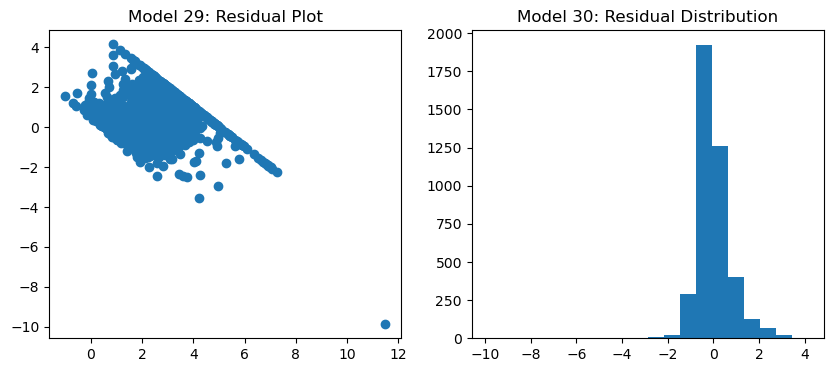

In [7]:
# Variations: Metric-based analysis and Residual Plots
# 26-28: Different Metrics
model = LinearRegression().fit(X_train, y_train)
preds = model.predict(X_test)
print(f"Model 26 (MSE): {mean_squared_error(y_test, preds):.4f}")
print(f"Model 27 (RMSE): {np.sqrt(mean_squared_error(y_test, preds)):.4f}")
print(f"Model 28 (R2): {r2_score(y_test, preds):.4f}")

# 29-30: Residual Analysis Plots
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(preds, y_test - preds) # Model 29
plt.title("Model 29: Residual Plot")

plt.subplot(1, 2, 2)
plt.hist(y_test - preds, bins=20) # Model 30
plt.title("Model 30: Residual Distribution")
plt.show()

---
### Quick Reference: The 30-Model Map

| **Model Range**    | **What is being tested?** | **Key Hyperparameter / Variant**                     |
| ------------------ | ------------------------- | ---------------------------------------------------- |
| **Models 1 – 5**   | Feature Subsets           | From 1 feature up to all 8 features                  |
| **Models 6 – 10**  | Preprocessing Scalers     | None, Standard, MinMax, Robust                       |
| **Models 11 – 15** | Model Complexity          | Polynomial Degrees (1 to 5) on `MedInc`              |
| **Models 16 – 20** | $L_2$ Regularization      | Ridge Alpha values ($0.1$ to $1000.0$)               |
| **Models 21 – 25** | $L_1$ Regularization      | Lasso Alpha values ($0.001$ to $10.0$)               |
| **Models 26 – 28** | Performance Evaluation    | MSE vs. RMSE vs. $R^2$ Metrics                       |
| **Models 29 – 30** | Error Diagnostics         | Residual Scatter Plot & Error Distribution Histogram |

---
### Core Takeaways of the Project
Ultimately, this project acts as a sandbox to prove that more complex isn't always better. By comparing the outputs of these 30 variations, you can pinpoint exactly where a model transitions from underfitting to hitting the sweet spot, and finally to overfitting, giving you a clear visual and mathematical narrative of the machine learning workflow.